<a href="https://colab.research.google.com/github/vladislav-bordiug/pyad-2024/blob/lab3/%D0%91%D0%BE%D1%80%D0%B4%D1%8E%D0%B3_%D0%9A%D0%BE%D0%BB%D1%81%D0%B0%D0%BD%D0%BE%D0%B2_3%D0%BB%D0%B0%D0%B1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 2

Добавил вывод функций потерь генератора и дискриминатора в зависимости от эпох для наглядности.

# Generative Adversarial Network

Общая архитектура. Суть задачи: научить нейросеть генерировать изображения одежды на основе данных Fashion-MNIST.

In [ ]:
import torch
torch.manual_seed(42)
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

# Гиперпараметры

In [ ]:
gpu = "cuda"
batch_size = 128
noise_vec_dim = 64

# optim parameters
lr = 0.0002
beta_1 = 0.5
beta_2 = 0.99

# training vars
epochs = 20

# Загрузка и аугментация данных

In [ ]:
from torchvision import datasets, transforms as T

In [ ]:
train_augs = T.Compose([
    T.RandomRotation((-20, +20)),
    T.ToTensor() # (h, w, c) -> (c, h, w)
])

In [ ]:
trainset = datasets.FashionMNIST("FashionMNIST/", download=True, train=True, transform=train_augs)

In [ ]:
print(f"Total images in trainset: {len(trainset)}")

Total images in trainset: 60000


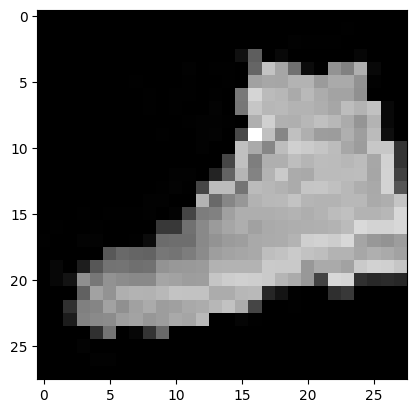

In [ ]:
image, label = trainset[50000]
plt.imshow(image.squeeze(), cmap="gray");

# Разбиение данных на батчи

In [ ]:
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

In [ ]:
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [ ]:
print(f"Total number of batches in trainloader: {len(trainloader)}")

Total number of batches in trainloader: 469


In [ ]:
for image, _ in trainloader:
  break

print(image.shape)

torch.Size([128, 1, 28, 28])


In [ ]:
# 'show_tensor_images' : function is used to plot some of images from the batch

def show_tensor_images(tensor_img, num_images = 16, size=(1, 28, 28)):
    unflat_img = tensor_img.detach().cpu()
    img_grid = make_grid(unflat_img[:num_images], nrow=4)
    plt.imshow(img_grid.permute(1, 2, 0).squeeze())
    plt.show()

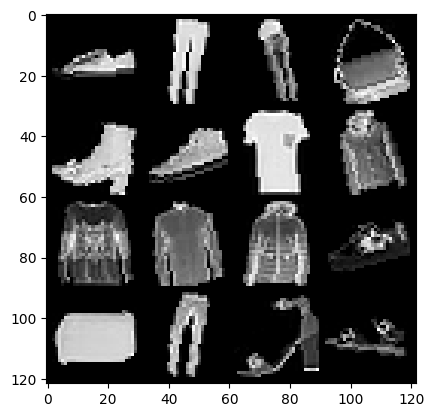

In [ ]:
show_tensor_images(image, num_images=16)

# Построение дискриминатора

Дискриминатором будет бинарный классификатор. Он попытается определить, настоящая ли картинка.

In [ ]:
#In case if torch summary is not installed

!pip install torchsummary

In [ ]:
from torch import nn
from torchsummary import summary

In [ ]:
'''
Архитектура дискриминатора.

Network : Discriminator

input : (bs, 1, 28, 28)
      |                                                                                               ---- SUMMARY ----
      V
Conv2d( in_channels = 1, out_channels = 16, kernel_size = (3,3), stride = 2)                           #(bs, 16, 13, 13)
BatchNorm2d()                                                                                          #(bs, 16, 13, 13)
LeakyReLU()                                                                                            #(bs, 16, 13, 13)
      |
      V
Conv2d( in_channels = 16, out_channels = 32, kernel_size = (5,5), stride = 2)                          #(bs, 32, 5, 5)
BatchNorm2d()                                                                                          #(bs, 32, 5, 5)
LeakyReLU()                                                                                            #(bs, 32, 5, 5)
      |
      V
Conv2d( in_channels = 32, out_channels = 64, kernel_size = (5,5), stride = 2)                          #(bs, 64, 1, 1)
BatchNorm2d()                                                                                          #(bs, 64, 1, 1)
LeakyReLU()                                                                                            #(bs, 64, 1, 1)
      |
      V
Flatten()                                                                                              #(bs, 64)
Linear(in_features = 64, out_features = 1)                                                             #(bs, 1)

'''

'\nАрхитектура дискриминатора.\n\nNetwork : Discriminator\n\ninput : (bs, 1, 28, 28)\n      |                                                                                               ---- SUMMARY ----\n      V\nConv2d( in_channels = 1, out_channels = 16, kernel_size = (3,3), stride = 2)                           #(bs, 16, 13, 13)\nBatchNorm2d()                                                                                          #(bs, 16, 13, 13)\nLeakyReLU()                                                                                            #(bs, 16, 13, 13)\n      |\n      V\nConv2d( in_channels = 16, out_channels = 32, kernel_size = (5,5), stride = 2)                          #(bs, 32, 5, 5)\nBatchNorm2d()                                                                                          #(bs, 32, 5, 5)\nLeakyReLU()                                                                                            #(bs, 32, 5, 5)\n      |\n      V\nConv2d( in_channels = 

In [ ]:
def get_disc_block(in_channels, out_channels, kernel_size, stride):
  return nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size, stride),
      nn.BatchNorm2d(out_channels),
      nn.LeakyReLU(0.2)
  )

In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()

    self.block_1 = get_disc_block(1, 16, (3, 3), 2)
    self.block_2 = get_disc_block(16, 32, (5, 5), 2)
    self.block_3 = get_disc_block(32, 64, (5,5), 2)

    self.flatten = nn.Flatten()
    self.linear = nn.Linear(64, 1)

  def forward(self, images):
    x1 = self.block_1(images)
    x2 = self.block_2(x1)
    x3 = self.block_3(x2)
    x4 = self.flatten(x3)
    x5 = self.linear(x4)

    return x5


In [ ]:
D = Discriminator()
D.to(gpu)

summary(D, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 13, 13]             160
       BatchNorm2d-2           [-1, 16, 13, 13]              32
         LeakyReLU-3           [-1, 16, 13, 13]               0
            Conv2d-4             [-1, 32, 5, 5]          12,832
       BatchNorm2d-5             [-1, 32, 5, 5]              64
         LeakyReLU-6             [-1, 32, 5, 5]               0
            Conv2d-7             [-1, 64, 1, 1]          51,264
       BatchNorm2d-8             [-1, 64, 1, 1]             128
         LeakyReLU-9             [-1, 64, 1, 1]               0
          Flatten-10                   [-1, 64]               0
           Linear-11                    [-1, 1]              65
Total params: 64,545
Trainable params: 64,545
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

# Построение генератора

In [ ]:
'''
Архитектура генератора.

Network : Generator

z_dim = 64
input : (bs,z_dim)

      |
      | Reshape
      V

input : (bs, channel, height, width) -> (bs, z_dim , 1 , 1)
      |                                                                                               ---- SUMMARY ----
      V
ConvTranspose2d( in_channels = z_dim, out_channels = 256, kernel_size = (3,3), stride = 2)             #(bs, 256, 3, 3)
BatchNorm2d()                                                                                          #(bs, 256, 3, 3)
ReLU()                                                                                                 #(bs, 256, 3, 3)
      |
      V
ConvTranspose2d( in_channels = 256, out_channels = 128, kernel_size = (4,4), stride = 1)               #(bs, 128, 6, 6)
BatchNorm2d()                                                                                          #(bs, 128, 6, 6)
ReLU()                                                                                                 #(bs, 128, 6, 6)
      |
      V
ConvTranspose2d( in_channels = 128, out_channels = 64, kernel_size = (3,3), stride = 2)                #(bs, 64, 13, 13)
BatchNorm2d()                                                                                          #(bs, 64, 13, 13)
ReLU()                                                                                                 #(bs, 64, 13, 13)
      |
      V
ConvTranspose2d( in_channels = 64, out_channels = 1, kernel_size = (4,4), stride = 2)                  #(bs, 1, 28, 28)
Tanh()                                                                                                 #(bs, 1, 28, 28)

'''

'\nАрхитектура генератора.\n\nNetwork : Generator\n\nz_dim = 64\ninput : (bs,z_dim)\n\n      |\n      | Reshape\n      V\n\ninput : (bs, channel, height, width) -> (bs, z_dim , 1 , 1)\n      |                                                                                               ---- SUMMARY ----\n      V\nConvTranspose2d( in_channels = z_dim, out_channels = 256, kernel_size = (3,3), stride = 2)             #(bs, 256, 3, 3)\nBatchNorm2d()                                                                                          #(bs, 256, 3, 3)\nReLU()                                                                                                 #(bs, 256, 3, 3)\n      |\n      V\nConvTranspose2d( in_channels = 256, out_channels = 128, kernel_size = (4,4), stride = 1)               #(bs, 128, 6, 6)\nBatchNorm2d()                                                                                          #(bs, 128, 6, 6)\nReLU()                                                        

In [ ]:
def get_gen_block(in_channels, out_channels, kernel_size, stride, final_block=False):
  if final_block:
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
        nn.Tanh()
    )
  return nn.Sequential(
      nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
      nn.BatchNorm2d(out_channels),
      nn.ReLU()
  )

In [ ]:
class Generator(nn.Module):
  def __init__(self, noise_vec_dim):
    super(Generator, self).__init__()

    self.noise_vec_dim = noise_vec_dim
    self.block_1 = get_gen_block(noise_vec_dim, 256, (3,3), 2)
    self.block_2 = get_gen_block(256, 128, (4,4), 1)
    self.block_3 = get_gen_block(128, 64, (3,3), 2)
    self.block_4 = get_gen_block(64, 1, (4,4), 2, final_block=True)

  def forward(self, random_noise_vec):
    # (b, noise_vec_dim) -> (b, noise_vec_dim, 1, 1)
    x = random_noise_vec.view(-1, self.noise_vec_dim, 1, 1)

    x1 = self.block_1(x)
    x2 = self.block_2(x1)
    x3 = self.block_3(x2)
    x4 = self.block_4(x3)

    return x4

In [ ]:
G = Generator(noise_vec_dim)
G.to(gpu)

summary(G, input_size=(1,noise_vec_dim))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 256, 3, 3]         147,712
       BatchNorm2d-2            [-1, 256, 3, 3]             512
              ReLU-3            [-1, 256, 3, 3]               0
   ConvTranspose2d-4            [-1, 128, 6, 6]         524,416
       BatchNorm2d-5            [-1, 128, 6, 6]             256
              ReLU-6            [-1, 128, 6, 6]               0
   ConvTranspose2d-7           [-1, 64, 13, 13]          73,792
       BatchNorm2d-8           [-1, 64, 13, 13]             128
              ReLU-9           [-1, 64, 13, 13]               0
  ConvTranspose2d-10            [-1, 1, 28, 28]           1,025
             Tanh-11            [-1, 1, 28, 28]               0
Total params: 747,841
Trainable params: 747,841
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

In [ ]:
# Инициализация начальных весов модели по нормальному распределению

def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
        nn.init.constant_(m.bias, 0)

In [ ]:
D = D.apply(weights_init)
G = G.apply(weights_init)

# Создание функции потерь и оптимизатора

In [ ]:
def real_loss(disc_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.ones_like(disc_pred)
  loss = criterion(disc_pred, ground_truth)
  return loss

def fake_loss(disc_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.zeros_like(disc_pred)
  loss = criterion(disc_pred, ground_truth)
  return loss

In [ ]:
D_opt = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta_1, beta_2))
G_opt = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta_1, beta_2))

# Обучение

In [ ]:
!pip install torchmetrics scipy

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 1 --- D_loss: 0.6830807292639319 --- G_loss: 0.6933079659303368


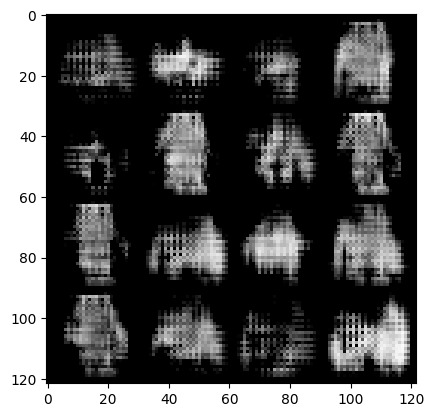

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 2 --- D_loss: 0.6714816013378884 --- G_loss: 0.7239400608453161


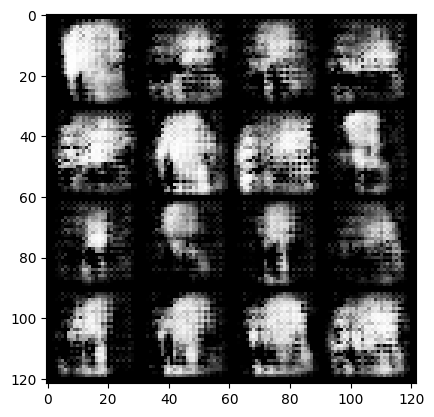

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 3 --- D_loss: 0.6496634606613534 --- G_loss: 0.7597594132809751


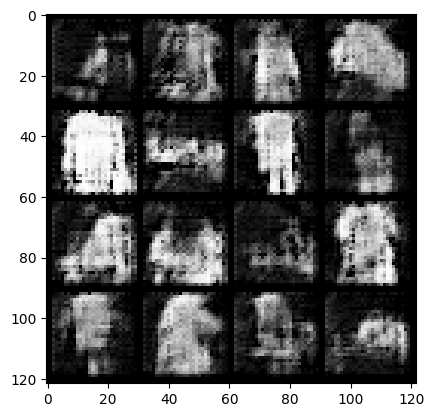

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 4 --- D_loss: 0.626238182917841 --- G_loss: 0.7946667390337376


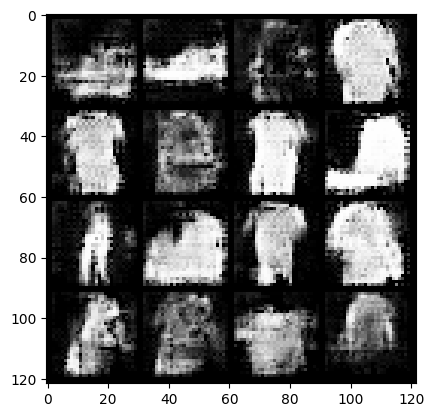

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 5 --- D_loss: 0.6138287789023507 --- G_loss: 0.8186886147903735


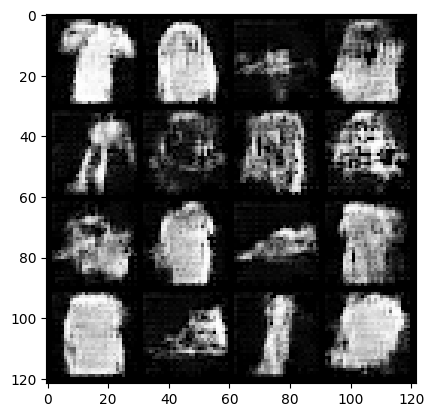

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 6 --- D_loss: 0.614213833422549 --- G_loss: 0.8225050001764602


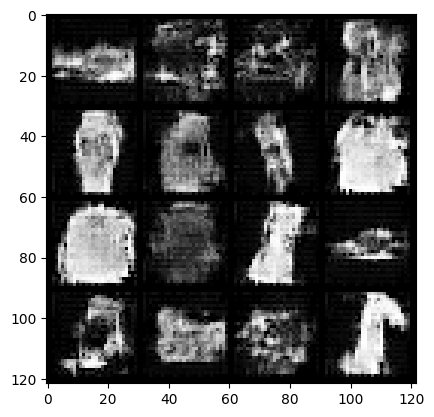

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 7 --- D_loss: 0.619121770106399 --- G_loss: 0.820873494595607


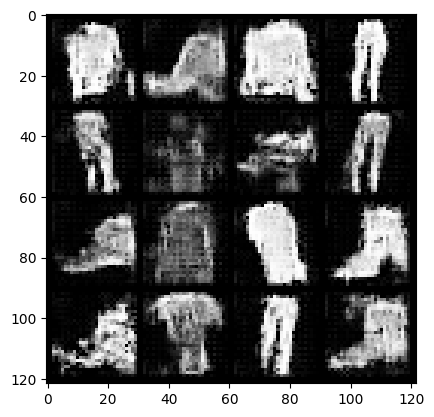

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 8 --- D_loss: 0.6219865865290546 --- G_loss: 0.8207362074333467


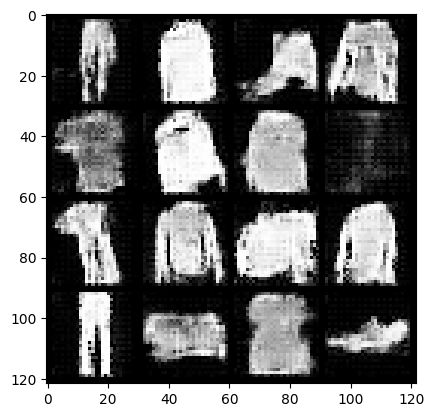

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 9 --- D_loss: 0.6243202102972246 --- G_loss: 0.8242847965216078


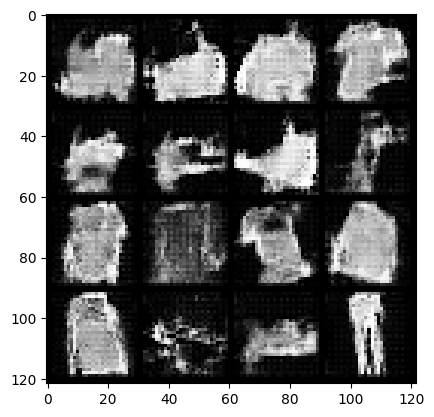

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 10 --- D_loss: 0.6239377827024155 --- G_loss: 0.8262545210974557


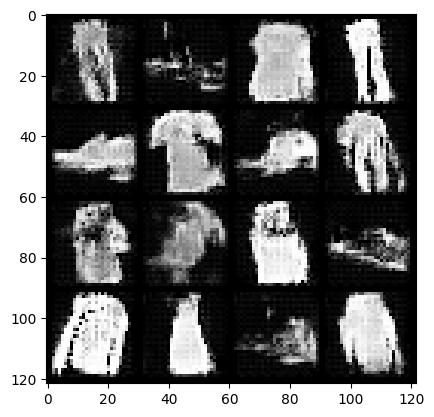

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 11 --- D_loss: 0.6253935585398156 --- G_loss: 0.8297043698174613


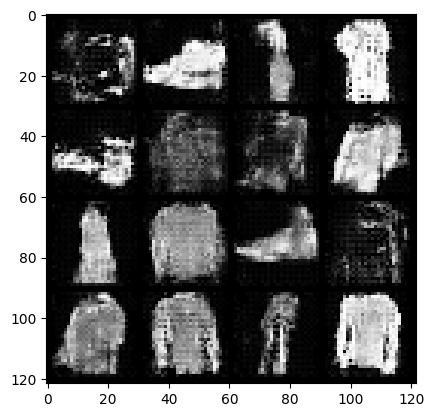

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 12 --- D_loss: 0.6268454366909669 --- G_loss: 0.8344027866432662


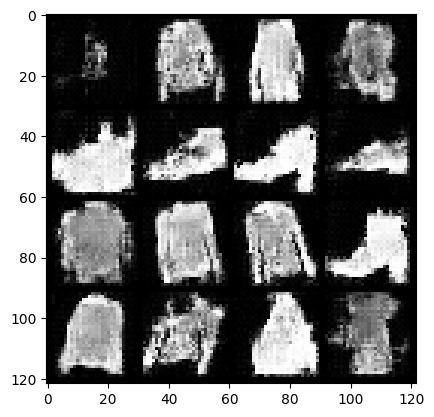

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 13 --- D_loss: 0.6296712962040769 --- G_loss: 0.8275702037790945


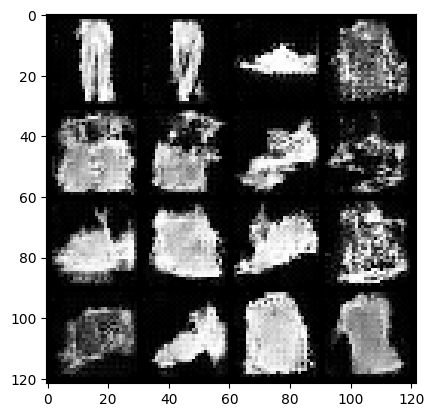

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 14 --- D_loss: 0.6308082352314931 --- G_loss: 0.8296916094670164


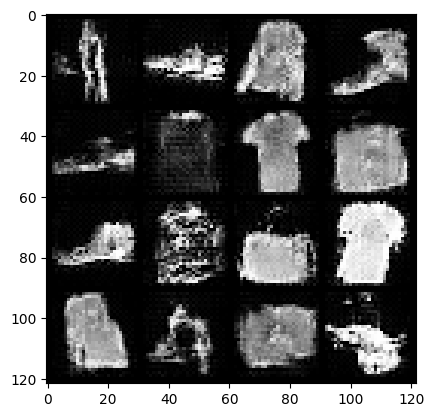

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 15 --- D_loss: 0.6322906953947884 --- G_loss: 0.8301199874135731


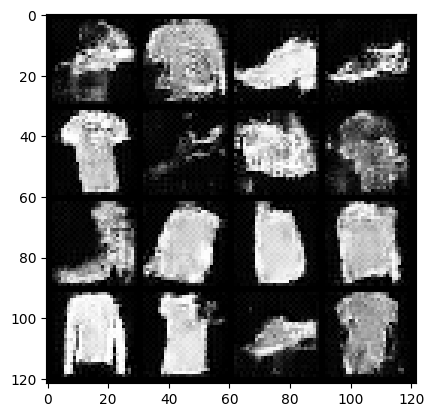

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 16 --- D_loss: 0.6331384096826825 --- G_loss: 0.8287003717696997


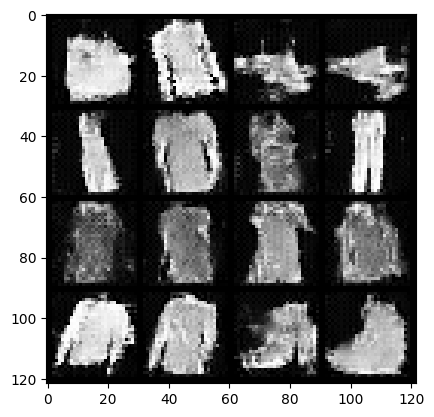

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 17 --- D_loss: 0.6335217410059117 --- G_loss: 0.8296708000748396


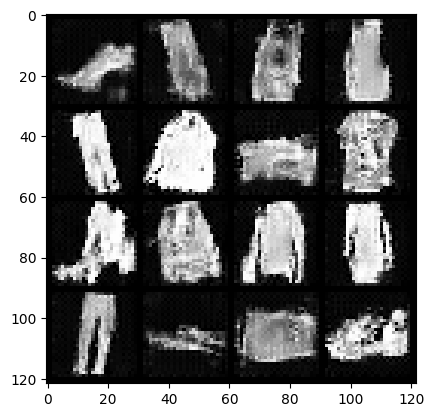

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 18 --- D_loss: 0.6350328696053674 --- G_loss: 0.83153462003289


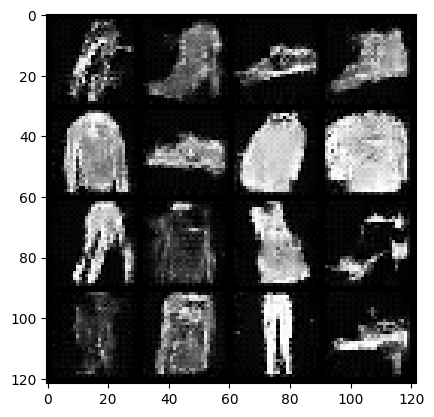

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 19 --- D_loss: 0.6345028784483481 --- G_loss: 0.8311335459701034


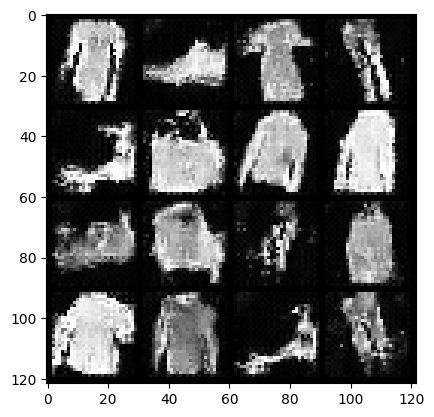

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 20 --- D_loss: 0.635350129497585 --- G_loss: 0.8314672985564925


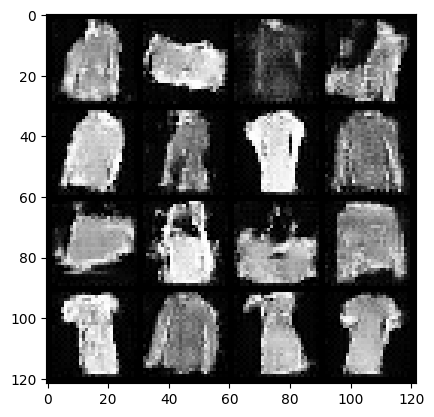

In [ ]:
from torchvision.models import inception_v3
from torch.nn.functional import softmax
from torchvision.transforms import Resize, Normalize
d_losses = []
g_losses = []

for i in range(epochs):
  total_d_loss = 0.0
  total_g_loss = 0.0

  for real_image, _ in tqdm(trainloader):
    real_image = real_image.to(gpu)

    # calculate loss and update weights for D
    D_opt.zero_grad()

    noise = torch.randn(batch_size, noise_vec_dim, device=gpu)
    fake_image = G(noise)
    D_pred = D(fake_image)
    D_fake_loss = fake_loss(D_pred)

    D_pred = D(real_image)
    D_real_loss = real_loss(D_pred)

    D_loss = (D_fake_loss + D_real_loss) / 2

    total_d_loss += D_loss.item()

    D_loss.backward()
    D_opt.step()

    # calculate loss and update weights for G
    G_opt.zero_grad()

    noise = torch.randn(batch_size, noise_vec_dim, device=gpu)
    fake_image = G(noise)
    D_pred = D(fake_image)
    G_loss = real_loss(D_pred)

    total_g_loss += G_loss.item()

    G_loss.backward()
    G_opt.step()

  avg_d_loss = total_d_loss / len(trainloader)
  avg_g_loss = total_g_loss / len(trainloader)

  d_losses.append(avg_d_loss)
  g_losses.append(avg_g_loss)

  print(f"Epoch: {i+1} --- D_loss: {avg_d_loss} --- G_loss: {avg_g_loss}")

  show_tensor_images(fake_image)

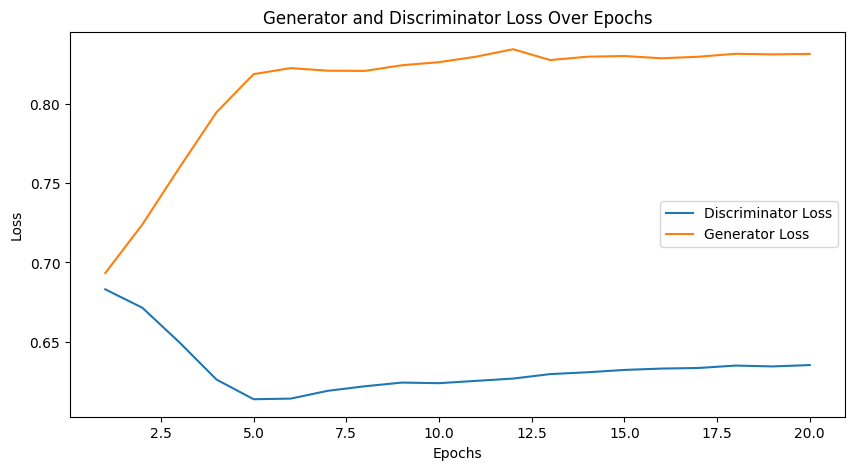

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), d_losses, label="Discriminator Loss")
plt.plot(range(1, epochs + 1), g_losses, label="Generator Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss Over Epochs")
plt.legend()
plt.show()

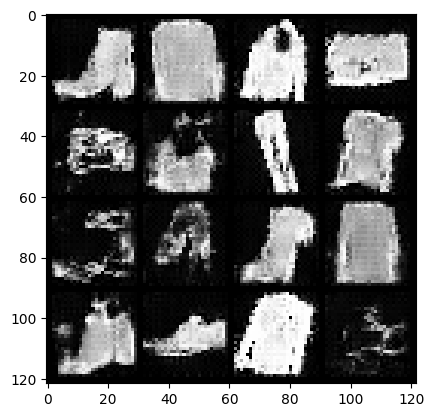

In [ ]:
# пример работы обученной сети
noise = torch.randn(batch_size, noise_vec_dim, device = gpu)
generated_image = G(noise)

show_tensor_images(generated_image)

# 4 пункт - Улучшение качества

Параметр lr был увеличен до 0,0003. Остальные параметры остались неизменными, т.к. в ходе экспериментов лучше качество изображений не становилось, только наоборот.

# Гиперпараметры

In [ ]:
gpu = "cuda"
batch_size = 128
noise_vec_dim = 64

# optim parameters
lr_g = 0.0003
beta_1 = 0.5
beta_2 = 0.999

# training vars
epochs = 20

# Загрузка и аугментация данных

In [ ]:
from torchvision import datasets, transforms as T

In [ ]:
train_augs = T.Compose([
    T.RandomRotation((-20, +20)),
    T.ToTensor() # (h, w, c) -> (c, h, w)
])

In [ ]:
trainset = datasets.FashionMNIST("FashionMNIST/", download=True, train=True, transform=train_augs)

In [ ]:
print(f"Total images in trainset: {len(trainset)}")

Total images in trainset: 60000


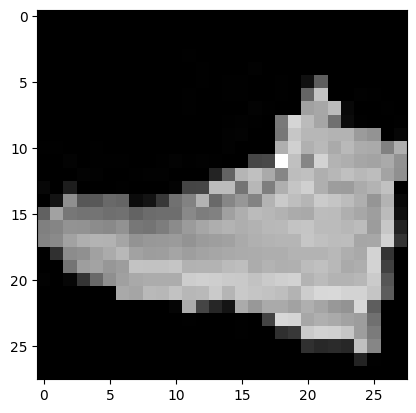

In [ ]:
image, label = trainset[50000]
plt.imshow(image.squeeze(), cmap="gray");

# Разбиение данных на батчи

In [ ]:
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

In [ ]:
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [ ]:
print(f"Total number of batches in trainloader: {len(trainloader)}")

Total number of batches in trainloader: 469


In [ ]:
for image, _ in trainloader:
  break

print(image.shape)

torch.Size([128, 1, 28, 28])


In [ ]:
# 'show_tensor_images' : function is used to plot some of images from the batch

def show_tensor_images(tensor_img, num_images = 16, size=(1, 28, 28)):
    unflat_img = tensor_img.detach().cpu()
    img_grid = make_grid(unflat_img[:num_images], nrow=4)
    plt.imshow(img_grid.permute(1, 2, 0).squeeze())
    plt.show()

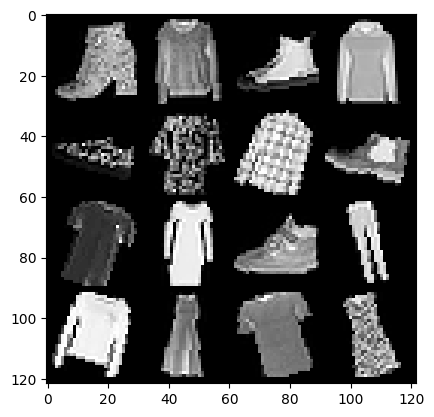

In [ ]:
show_tensor_images(image, num_images=16)

# Построение дискриминатора

Дискриминатором будет бинарный классификатор. Он попытается определить, настоящая ли картинка.

In [ ]:
#In case if torch summary is not installed

!pip install torchsummary

In [ ]:
from torch import nn
from torchsummary import summary

In [ ]:
'''
Архитектура дискриминатора.

Network : Discriminator

input : (bs, 1, 28, 28)
      |                                                                                               ---- SUMMARY ----
      V
Conv2d( in_channels = 1, out_channels = 16, kernel_size = (3,3), stride = 2)                           #(bs, 16, 13, 13)
BatchNorm2d()                                                                                          #(bs, 16, 13, 13)
LeakyReLU()                                                                                            #(bs, 16, 13, 13)
      |
      V
Conv2d( in_channels = 16, out_channels = 32, kernel_size = (5,5), stride = 2)                          #(bs, 32, 5, 5)
BatchNorm2d()                                                                                          #(bs, 32, 5, 5)
LeakyReLU()                                                                                            #(bs, 32, 5, 5)
      |
      V
Conv2d( in_channels = 32, out_channels = 64, kernel_size = (5,5), stride = 2)                          #(bs, 64, 1, 1)
BatchNorm2d()                                                                                          #(bs, 64, 1, 1)
LeakyReLU()                                                                                            #(bs, 64, 1, 1)
      |
      V
Flatten()                                                                                              #(bs, 64)
Linear(in_features = 64, out_features = 1)                                                             #(bs, 1)

'''

'\nАрхитектура дискриминатора.\n\nNetwork : Discriminator\n\ninput : (bs, 1, 28, 28)\n      |                                                                                               ---- SUMMARY ----\n      V\nConv2d( in_channels = 1, out_channels = 16, kernel_size = (3,3), stride = 2)                           #(bs, 16, 13, 13)\nBatchNorm2d()                                                                                          #(bs, 16, 13, 13)\nLeakyReLU()                                                                                            #(bs, 16, 13, 13)\n      |\n      V\nConv2d( in_channels = 16, out_channels = 32, kernel_size = (5,5), stride = 2)                          #(bs, 32, 5, 5)\nBatchNorm2d()                                                                                          #(bs, 32, 5, 5)\nLeakyReLU()                                                                                            #(bs, 32, 5, 5)\n      |\n      V\nConv2d( in_channels = 

In [ ]:
def get_disc_block(in_channels, out_channels, kernel_size, stride):
  return nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size, stride),
      nn.BatchNorm2d(out_channels),
      nn.LeakyReLU(0.2)
  )

In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()

    self.block_1 = get_disc_block(1, 16, (3, 3), 2)
    self.block_2 = get_disc_block(16, 32, (5, 5), 2)
    self.block_3 = get_disc_block(32, 64, (5,5), 2)

    self.flatten = nn.Flatten()
    self.linear = nn.Linear(64, 1)

  def forward(self, images):
    x1 = self.block_1(images)
    x2 = self.block_2(x1)
    x3 = self.block_3(x2)
    x4 = self.flatten(x3)
    x5 = self.linear(x4)

    return x5


In [ ]:
D = Discriminator()
D.to(gpu)

summary(D, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 13, 13]             160
       BatchNorm2d-2           [-1, 16, 13, 13]              32
         LeakyReLU-3           [-1, 16, 13, 13]               0
            Conv2d-4             [-1, 32, 5, 5]          12,832
       BatchNorm2d-5             [-1, 32, 5, 5]              64
         LeakyReLU-6             [-1, 32, 5, 5]               0
            Conv2d-7             [-1, 64, 1, 1]          51,264
       BatchNorm2d-8             [-1, 64, 1, 1]             128
         LeakyReLU-9             [-1, 64, 1, 1]               0
          Flatten-10                   [-1, 64]               0
           Linear-11                    [-1, 1]              65
Total params: 64,545
Trainable params: 64,545
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

# Построение генератора

In [ ]:
'''
Архитектура генератора.

Network : Generator

z_dim = 64
input : (bs,z_dim)

      |
      | Reshape
      V

input : (bs, channel, height, width) -> (bs, z_dim , 1 , 1)
      |                                                                                               ---- SUMMARY ----
      V
ConvTranspose2d( in_channels = z_dim, out_channels = 256, kernel_size = (3,3), stride = 2)             #(bs, 256, 3, 3)
BatchNorm2d()                                                                                          #(bs, 256, 3, 3)
ReLU()                                                                                                 #(bs, 256, 3, 3)
      |
      V
ConvTranspose2d( in_channels = 256, out_channels = 128, kernel_size = (4,4), stride = 1)               #(bs, 128, 6, 6)
BatchNorm2d()                                                                                          #(bs, 128, 6, 6)
ReLU()                                                                                                 #(bs, 128, 6, 6)
      |
      V
ConvTranspose2d( in_channels = 128, out_channels = 64, kernel_size = (3,3), stride = 2)                #(bs, 64, 13, 13)
BatchNorm2d()                                                                                          #(bs, 64, 13, 13)
ReLU()                                                                                                 #(bs, 64, 13, 13)
      |
      V
ConvTranspose2d( in_channels = 64, out_channels = 1, kernel_size = (4,4), stride = 2)                  #(bs, 1, 28, 28)
Tanh()                                                                                                 #(bs, 1, 28, 28)

'''

'\nАрхитектура генератора.\n\nNetwork : Generator\n\nz_dim = 64\ninput : (bs,z_dim)\n\n      |\n      | Reshape\n      V\n\ninput : (bs, channel, height, width) -> (bs, z_dim , 1 , 1)\n      |                                                                                               ---- SUMMARY ----\n      V\nConvTranspose2d( in_channels = z_dim, out_channels = 256, kernel_size = (3,3), stride = 2)             #(bs, 256, 3, 3)\nBatchNorm2d()                                                                                          #(bs, 256, 3, 3)\nReLU()                                                                                                 #(bs, 256, 3, 3)\n      |\n      V\nConvTranspose2d( in_channels = 256, out_channels = 128, kernel_size = (4,4), stride = 1)               #(bs, 128, 6, 6)\nBatchNorm2d()                                                                                          #(bs, 128, 6, 6)\nReLU()                                                        

In [ ]:
def get_gen_block(in_channels, out_channels, kernel_size, stride, final_block=False):
  if final_block:
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
        nn.Tanh()
    )
  return nn.Sequential(
      nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
      nn.BatchNorm2d(out_channels),
      nn.ReLU()
  )

In [ ]:
class Generator(nn.Module):
  def __init__(self, noise_vec_dim):
    super(Generator, self).__init__()

    self.noise_vec_dim = noise_vec_dim
    self.block_1 = get_gen_block(noise_vec_dim, 256, (3,3), 2)
    self.block_2 = get_gen_block(256, 128, (4,4), 1)
    self.block_3 = get_gen_block(128, 64, (3,3), 2)
    self.block_4 = get_gen_block(64, 1, (4,4), 2, final_block=True)

  def forward(self, random_noise_vec):
    # (b, noise_vec_dim) -> (b, noise_vec_dim, 1, 1)
    x = random_noise_vec.view(-1, self.noise_vec_dim, 1, 1)

    x1 = self.block_1(x)
    x2 = self.block_2(x1)
    x3 = self.block_3(x2)
    x4 = self.block_4(x3)

    return x4

In [ ]:
G = Generator(noise_vec_dim)
G.to(gpu)

summary(G, input_size=(1,noise_vec_dim))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 256, 3, 3]         147,712
       BatchNorm2d-2            [-1, 256, 3, 3]             512
              ReLU-3            [-1, 256, 3, 3]               0
   ConvTranspose2d-4            [-1, 128, 6, 6]         524,416
       BatchNorm2d-5            [-1, 128, 6, 6]             256
              ReLU-6            [-1, 128, 6, 6]               0
   ConvTranspose2d-7           [-1, 64, 13, 13]          73,792
       BatchNorm2d-8           [-1, 64, 13, 13]             128
              ReLU-9           [-1, 64, 13, 13]               0
  ConvTranspose2d-10            [-1, 1, 28, 28]           1,025
             Tanh-11            [-1, 1, 28, 28]               0
Total params: 747,841
Trainable params: 747,841
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

In [ ]:
# Инициализация начальных весов модели по нормальному распределению

def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
        nn.init.constant_(m.bias, 0)

In [ ]:
D = D.apply(weights_init)
G = G.apply(weights_init)

# Создание функции потерь и оптимизатора

In [ ]:
def real_loss(disc_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.ones_like(disc_pred)
  loss = criterion(disc_pred, ground_truth)
  return loss

def fake_loss(disc_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.zeros_like(disc_pred)
  loss = criterion(disc_pred, ground_truth)
  return loss

In [ ]:
D_opt = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta_1, beta_2))
G_opt = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta_1, beta_2))

# Обучение

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 1 --- D_loss: 0.686728263968852 --- G_loss: 0.7136768828322892


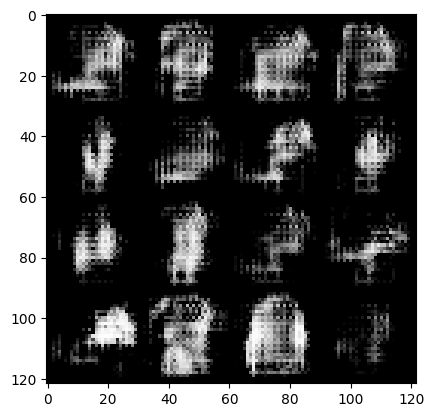

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 2 --- D_loss: 0.6659418367373664 --- G_loss: 0.738170885709303


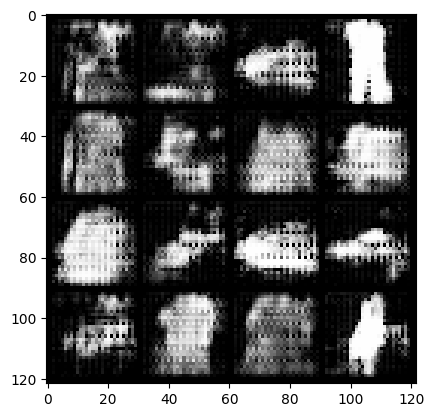

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 3 --- D_loss: 0.6102124808439567 --- G_loss: 0.8475789840795847


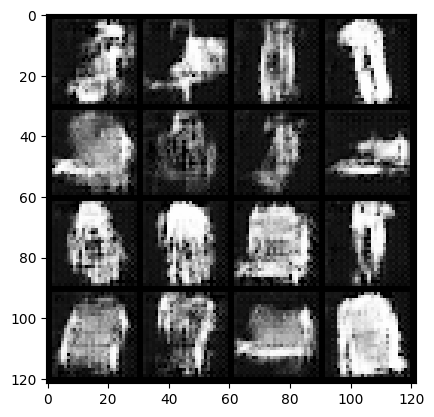

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 4 --- D_loss: 0.5767523262546514 --- G_loss: 0.9259011402313135


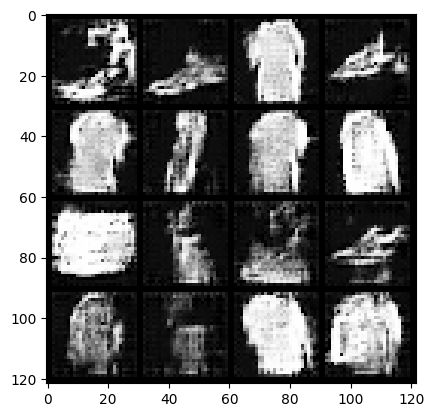

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 5 --- D_loss: 0.5703199676104954 --- G_loss: 0.9408999075259227


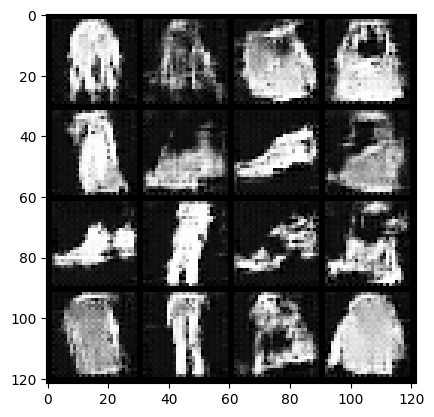

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 6 --- D_loss: 0.5637901488906031 --- G_loss: 0.9513824331734989


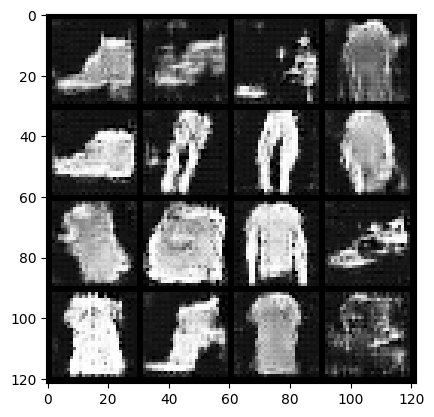

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 7 --- D_loss: 0.5606868338229051 --- G_loss: 0.9625614762052036


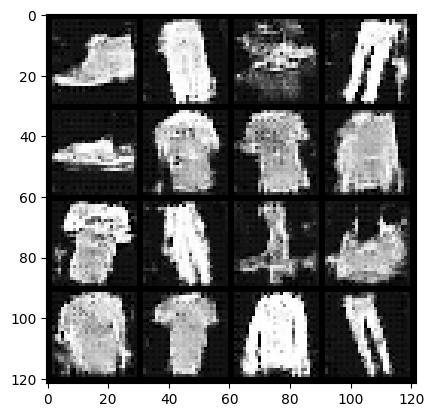

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 8 --- D_loss: 0.5638559541976782 --- G_loss: 0.9676822559919946


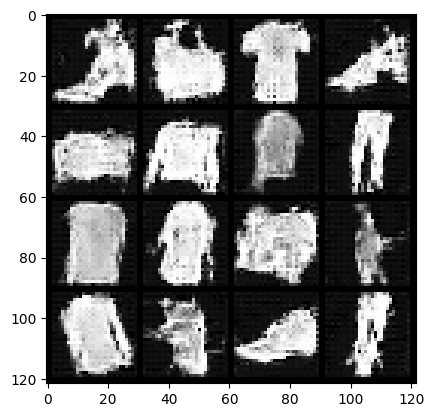

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 9 --- D_loss: 0.5651960478408504 --- G_loss: 0.977451723775884


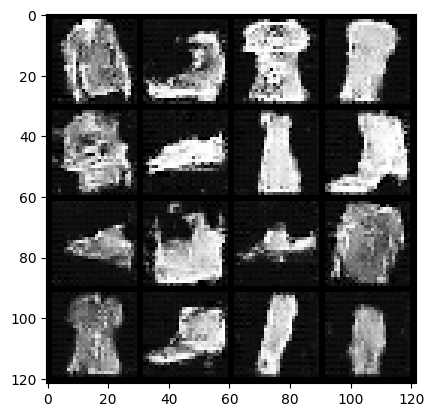

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 10 --- D_loss: 0.5671997980268271 --- G_loss: 0.980993232111941


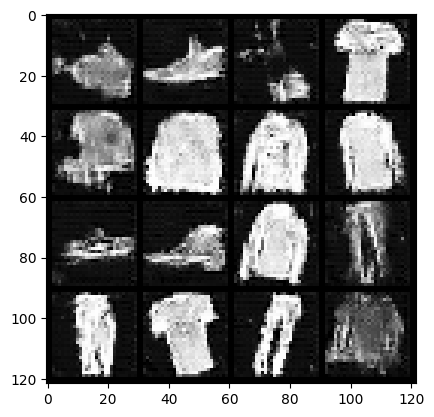

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 11 --- D_loss: 0.5677911229352198 --- G_loss: 0.9879580184594908


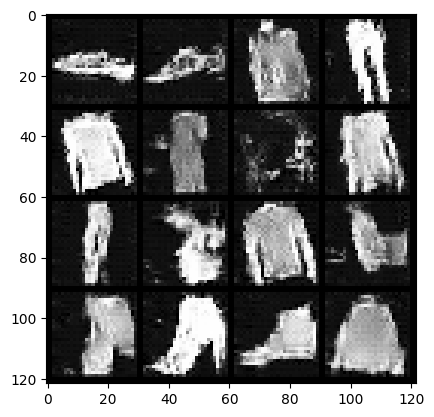

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 12 --- D_loss: 0.5693483979208891 --- G_loss: 0.9888855018087034


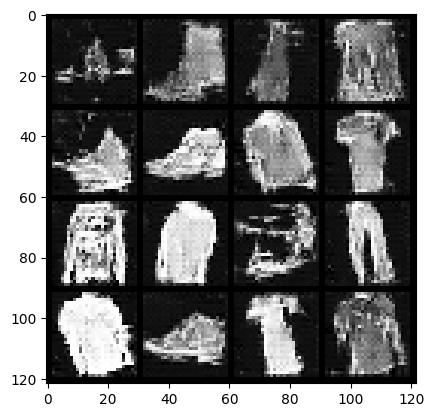

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 13 --- D_loss: 0.5724920831255312 --- G_loss: 0.9832571823713876


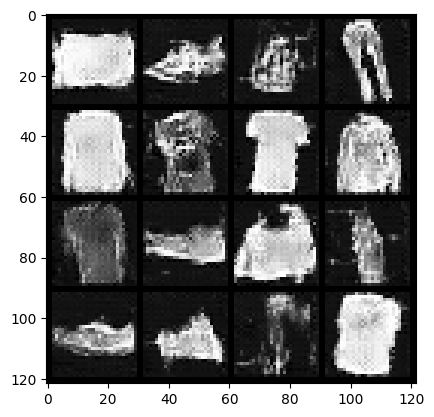

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 14 --- D_loss: 0.5741735038472645 --- G_loss: 0.9849815627913485


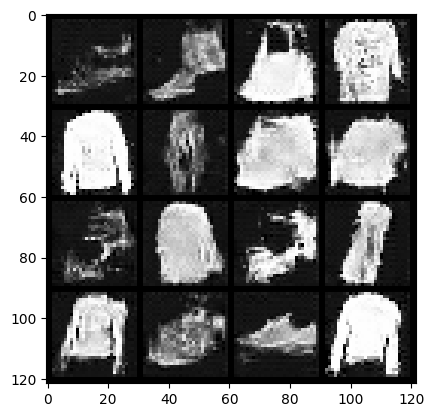

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 15 --- D_loss: 0.57541037603482 --- G_loss: 0.9909527660178732


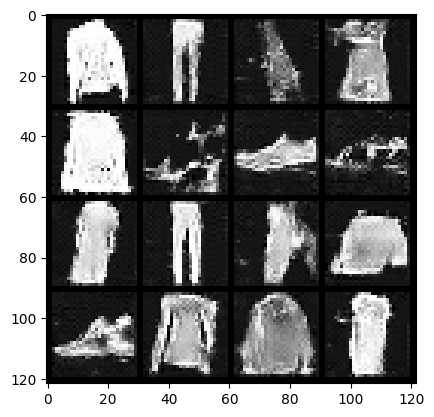

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 16 --- D_loss: 0.5777332181615362 --- G_loss: 0.9858036451756573


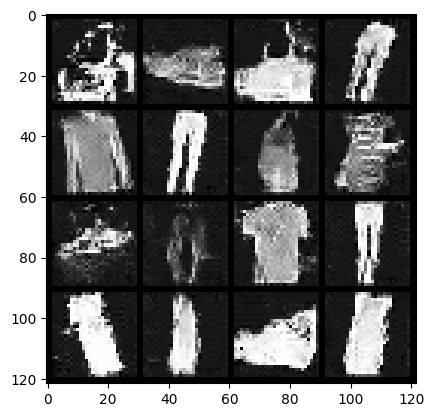

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 17 --- D_loss: 0.5800801368156222 --- G_loss: 0.9934024644304694


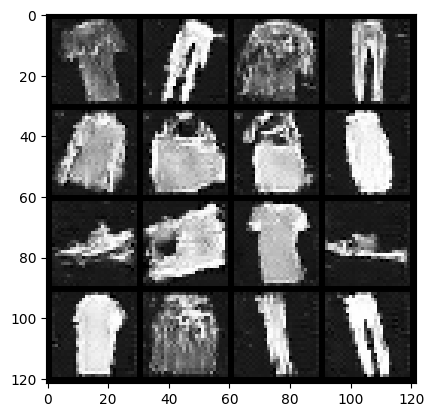

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 18 --- D_loss: 0.5802735574464045 --- G_loss: 0.9917425336614092


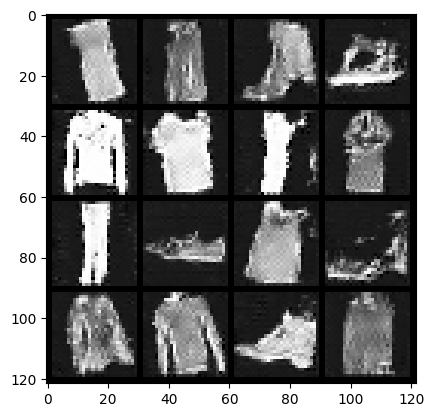

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 19 --- D_loss: 0.5767596634720434 --- G_loss: 0.9993731432886266


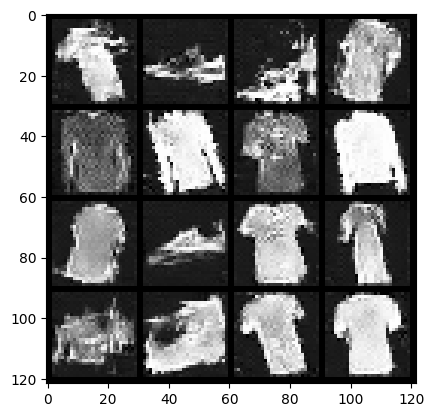

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 20 --- D_loss: 0.5749937895772808 --- G_loss: 1.0115616654536363


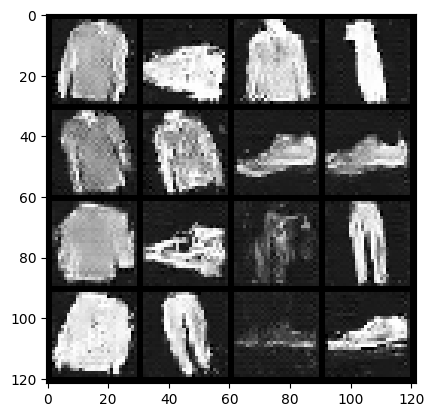

In [ ]:
d_losses = []
g_losses = []

for i in range(epochs):
  total_d_loss = 0.0
  total_g_loss = 0.0

  for real_image, _ in tqdm(trainloader):
    real_image = real_image.to(gpu)

    # calculate loss and update weights for D
    D_opt.zero_grad()

    noise = torch.randn(batch_size, noise_vec_dim, device=gpu)
    fake_image = G(noise)
    D_pred = D(fake_image)
    D_fake_loss = fake_loss(D_pred)

    D_pred = D(real_image)
    D_real_loss = real_loss(D_pred)

    D_loss = (D_fake_loss + D_real_loss) / 2

    total_d_loss += D_loss.item()

    D_loss.backward()
    D_opt.step()

    # calculate loss and update weights for G
    G_opt.zero_grad()

    noise = torch.randn(batch_size, noise_vec_dim, device=gpu)
    fake_image = G(noise)
    D_pred = D(fake_image)
    G_loss = real_loss(D_pred)

    total_g_loss += G_loss.item()

    G_loss.backward()
    G_opt.step()

  avg_d_loss = total_d_loss / len(trainloader)
  avg_g_loss = total_g_loss / len(trainloader)

  d_losses.append(avg_d_loss)
  g_losses.append(avg_g_loss)

  print(f"Epoch: {i+1} --- D_loss: {avg_d_loss} --- G_loss: {avg_g_loss}")

  show_tensor_images(fake_image)

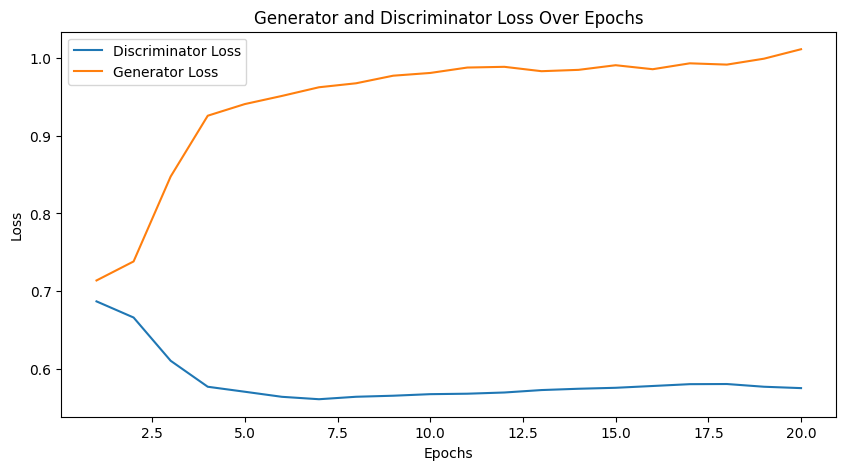

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), d_losses, label="Discriminator Loss")
plt.plot(range(1, epochs + 1), g_losses, label="Generator Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss Over Epochs")
plt.legend()
plt.show()

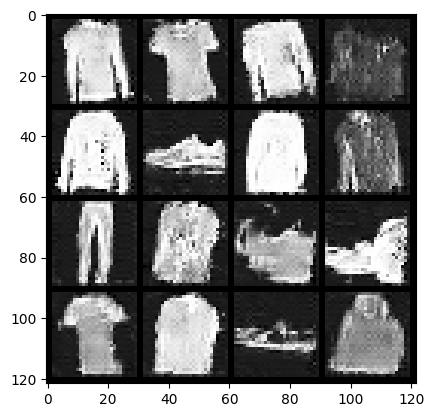

In [ ]:
# пример работы обученной сети
noise = torch.randn(batch_size, noise_vec_dim, device = gpu)
generated_image = G(noise)

show_tensor_images(generated_image)

Параметр lr был увеличен до 0,0003. Остальные параметры остались неизменными, т.к. в ходе экспериментов лучше качество изображений не становилось, только наоборот.

## Вывод
В этот раз значение функции потери дискриминатора оказалось ближе к 0,5, что лучше, функция потери генератора около 1, обе функции потери стабилизировались после 7 эпох. Качество изображений также улучшилось визуально.